# 🌊 Analisi di onde e maree per la stima del runup costiero

Benvenuti a questa esercitazione pratica dedicata all’**analisi di onde e maree**!  
In questo notebook impareremo a usare **Python** per studiare come le onde interagiscono con la costa e come stimare l’altezza massima raggiunta dal moto ondoso sulla spiaggia — il cosiddetto *wave runup*.

Durante l’attività vedremo come:

1. 📂 **Caricare ed esplorare dati** di onde e maree da file CSV.
2. 📈 **Visualizzare** serie temporali di onde e livelli di marea.
3. 🌊 **Stimare il runup costiero** utilizzando un pacchetto Python specifico.

---

🧠 **Obiettivo didattico**  
Questo notebook è pensato per studenti di **Scienze Ambientali o Scienze della Terra**, anche senza precedenti esperienze di programmazione.  
Troverai molti commenti e spiegazioni passo passo: il nostro obiettivo è **imparare facendo** (*learn by doing*).  

💡 **Suggerimento:**  
Puoi modificare il codice e rieseguirlo (⇧ + ⏎) per vedere cosa succede.  
Usa le celle di testo (*Markdown*) per prendere appunti e descrivere i risultati delle tue analisi.

## 📂 Accesso ai dati su Google Drive

In questo passaggio impareremo a **collegare il nostro Google Drive** a Colab, così da poter lavorare direttamente con i file salvati nel nostro spazio personale.

Faremo tre operazioni principali:

1. 🔗 **Montare Google Drive** — in modo che Colab possa leggere e scrivere file nelle tue cartelle.  
2. 📁 **Impostare la cartella di lavoro** — specificando dove si trovano i dati e gli script del progetto.  
3. 🧩 *(Facoltativo)* **Aggiungere una cartella al “Python path”** — così possiamo importare funzioni direttamente da file `.py` scaricati, ad esempio il modello di *wave runup*.

---

> 🔁 **Importante:**  
> Se è **la prima volta** che esegui questo notebook, dovrai **decommentare** la riga che inizia con `!git clone` per scaricare il modello *wave runup* da GitHub.  
> Questa operazione va fatta **una sola volta** — in seguito la cartella sarà già presente nel tuo Drive.

💡 **Suggerimento per chi usa Colab:**  
Quando esegui la cella di montaggio di Drive, Colab ti chiederà di autorizzare l’accesso.

In [1]:
# --- 🔧 Collegamento a Google Drive e impostazione della cartella di lavoro ---
from google.colab import drive
import os
import sys

# 🔗 Monta Google Drive (ti verrà chiesto di autorizzare l'accesso)
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
# 📁 Imposta la cartella di lavoro principale
# 👉 Modifica il percorso se hai salvato il progetto in una posizione diversa
working_dir = '/content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup'

# 🔄 Spostati nella cartella di lavoro
%cd $working_dir

# Percorso della sottocartella "Risultati"
results_dir = os.path.join(working_dir, "Risultati")
# Crea la cartella se non esiste già
os.makedirs(results_dir, exist_ok=True)

# 🧩 (Facoltativo) Clona il repository GitHub se non è già presente
# Rimuovi il simbolo "#" dalla riga qui sotto e riesegui la cella solo la prima volta
#!git clone https://github.com/chrisleaman/py-wave-runup.git

# ➕ Aggiunge la cartella contenente models.py al percorso di Python
# In questo modo potremo importare le funzioni del modello wave runup
models_path = os.path.join(working_dir, 'py-wave-runup')
sys.path.append(models_path)

/content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup


In [3]:
# --- 🎲 Seed riproducibile per questa copia del notebook ---
# Obiettivo: generare un seed la prima volta e salvarlo su disco
# In questo modo, tutte le riesecuzioni nella stessa cartella useranno lo stesso seed
# ma copie diverse del notebook (o in cartelle diverse) avranno seed diversi.

seed_file = Path(working_dir) / "random_seed.json"

def _make_new_seed():
    # Mescoliamo diverse fonti (tempo + entropia OS + path) e poi facciamo un hash
    mix = f"{time.time_ns()}::{os.urandom(16).hex()}::{working_dir}"
    h = hashlib.blake2s(mix.encode(), digest_size=8).hexdigest()
    return int(h, 16) % (2**32 - 1)

if seed_file.exists():
    with open(seed_file, "r") as f:
        seed = json.load(f).get("seed", 123456789)
else:
    seed = _make_new_seed()
    with open(seed_file, "w") as f:
        json.dump({"seed": seed}, f)

rng = np.random.default_rng(seed)

print(f"Seed attivo per questa cartella: {seed}")

Seed attivo per questa cartella: 128520515


## 🧰 Importazione delle librerie

Prima di iniziare a lavorare con i dati, dobbiamo **importare alcune librerie di Python**.  
Le librerie sono “scatole di strumenti” che contengono funzioni già pronte per svolgere operazioni specifiche, come leggere dati, creare grafici o fare calcoli.

In questa esercitazione useremo:

- 📊 **`pandas`** — per caricare, esplorare e manipolare dati (ad esempio da file `.csv`).  
- 📈 **`matplotlib`** e **`seaborn`** — per creare grafici e visualizzazioni dei dati.  
- 🎛️ **`ipywidgets`** — per aggiungere elementi interattivi (menu a tendina, slider, pulsanti).  
- ➕ **`numpy`** — per lavorare con numeri, array e operazioni matematiche.  
- 🌊 **`py_wave_runup`** — per stimare il *wave runup* usando modelli fisici già implementati.

---

Importando queste librerie ora, prepariamo l’ambiente di lavoro per:
1. leggere i dati da file,
2. analizzarli e trasformarli,
3. rappresentarli graficamente in modo chiaro e interattivo.

💡 **Suggerimento:**  
In Colab o Jupyter puoi eseguire una cella di codice con **Shift + Invio (⇧ + ⏎)**.  
Se tutto è installato correttamente, non dovrebbero comparire messaggi di errore dopo l’importazione.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
from py_wave_runup import models
import os, json, hashlib, time
import numpy as np
from pathlib import Path

## 📄 Caricamento e pulizia dei dati di marea e di onda

In questo passaggio caricheremo due file in formato **CSV** che contengono le nostre osservazioni:

- **`Tide_Gauge.csv`** → misura il livello del mare registrato da un mareografo nel tempo.  
- **`Wave_buoy.csv`** → contiene le condizioni del moto ondoso, come:
  - l’altezza significativa dell’onda (`Hs`),  
  - il periodo medio (`Tmean`).

---

### 🔧 Cosa faremo
Utilizzeremo la libreria **`pandas`** per:

1. 📥 **Leggere i dati** dai file CSV.  
2. 🕒 **Combinare e convertire** le colonne di data e ora nel formato temporale corretto (`datetime`).  
3. 🧹 **Pulire i dati**, eliminando eventuali valori mancanti o non validi.  
4. 🧭 **Impostare la colonna temporale come indice**, in modo da poter allineare in seguito i dati di marea e di onda.

---

### 🎯 Obiettivo
Alla fine di questo passaggio, avremo due tabelle ordinate e pulite — una per le maree e una per le onde — **pronte per essere analizzate e visualizzate** nei passaggi successivi.

💡 *Suggerimento:* se compare un errore di tipo “file not found”, controlla che il percorso del file (`tide_file_path` e `wave_file_path`) sia corretto e che i file si trovino nella cartella `Dati_originali/` del tuo Drive.

In [5]:
# --- 🌊📈 Importazione dei dati di marea e onde ---

# Percorsi dei file (modifica se i dati si trovano altrove)
tide_file_path = 'Dati_originali/Tide_Gauge.csv'
wave_file_path = 'Dati_originali/Wave_buoy.csv'

print("Caricamento dei dati in corso...")

# --- Lettura dati di marea ---
tides_df = pd.read_csv(tide_file_path, sep=';', dtype=str)

# Combina le colonne DATE e TIME in un'unica colonna datetime
tides_df['Datetime'] = pd.to_datetime(
    tides_df['DATE'] + tides_df['TIME'],
    format='%Y%m%d%H:%M',
    errors='coerce'
)

# Pulisce la colonna WaterLevel (converti in numerico, rimuovi NaN)
tides_df['WaterLevel'] = pd.to_numeric(tides_df['WaterLevel'], errors='coerce')
tides_df = tides_df.dropna(subset=['WaterLevel'])

# Imposta Datetime come indice
tides_df = tides_df.set_index('Datetime')

print(f"✅ Dati di marea caricati: {len(tides_df)} righe")

# --- Lettura dati di onde ---
waves_df = pd.read_csv(wave_file_path)

# Converte la colonna Datetime nel formato corretto
waves_df['Datetime'] = pd.to_datetime(
    waves_df['Datetime'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Imposta Datetime come indice
waves_df = waves_df.set_index('Datetime')

# Conversione sicura dei valori numerici
for col in ['Hs', 'Tmean']:
    waves_df[col] = pd.to_numeric(waves_df[col], errors='coerce')

waves_df = waves_df.dropna(subset=['Hs', 'Tmean'])

print(f"✅ Dati di onde caricati: {len(waves_df)} righe")

Caricamento dei dati in corso...
✅ Dati di marea caricati: 432 righe
✅ Dati di onde caricati: 141 righe


## 🎲 Creazione di dati leggermente diversi per ogni esercizio

In questa parte del notebook, aggiungiamo una **piccola variazione casuale ma realistica** ai dati originali di marea e di onda.

---

### 🎯 Perché lo facciamo
Ogni studente o studentessa avrà un **dataset unico**, con valori leggermente diversi ma sempre coerenti con la realtà fisica.  
In questo modo:
- tutti seguono **lo stesso esercizio** e ottengono **risultati confrontabili**,  
- ma ciascuno lavora su **numeri diversi**, rendendo l’attività più personale e meno meccanica.

Queste piccole differenze permettono anche di discutere in classe come **modeste variazioni nei dati osservati** possano influenzare le analisi e le conclusioni sui processi costieri.

---

### ⚙️ Come funziona
Il codice crea due nuove tabelle:

- **`tides_df_pert`** → versione *perturbata* dei dati di marea  
  (si aggiunge un rumore *additivo* con andamento realistico, che simula leggere variazioni dovute a fenomeni meteorologici o al rumore strumentale).  
  Il segnale include:
  - un **drift lento** (variazioni su scale di alcune ore, come piccoli *surge*);
  - **sinusoidi a bassa frequenza** per imitare cicli lunghi di marea o pressione;
  - un lieve **rumore bianco residuo** e uno **smussamento finale** per rendere la curva continua.

- **`waves_df_pert`** → versione perturbata dei dati di onde  
  (si applica un rumore *moltiplicativo* del ±5–8% su `Hs` e `Tmean`, per rappresentare la variabilità tipica delle boe d’onda).

---

### 🧠 Riproducibilità
Per evitare confusione:
- lo **stesso notebook**, se salvato nella stessa cartella, produrrà **sempre gli stessi dati perturbati** (grazie a un *seed* salvato localmente);
- copie del notebook in altre cartelle genereranno invece **dati diversi**, creando esercizi unici per ogni studente.

💡 *In questo modo ogni persona lavora su un dataset diverso, ma i risultati rimangono scientificamente comparabili e coerenti tra tutti!*

In [6]:
# --- 🌊🔧 Perturbazione controllata e realistica dei dati di marea e onda ---
# Obiettivo:
# - tides_df_pert: rumore ADDITIVO "mareografico" (cm) su WaterLevel
# - waves_df_pert: rumore MOLTIPLICATIVO (%) su Hs e Tmean
#   (il rumore è liscio/autocorrelato nel tempo)

# === Utilità per rumore "liscio" (per le onde) ===
def smooth_noise(n, rng, scale=1.0, window=25):
    """Rumore gaussiano smussato con media mobile per creare autocorrelazione."""
    raw = rng.normal(loc=0.0, scale=scale, size=n)
    if window > 1:
        kernel = np.ones(window) / window
        smoothed = np.convolve(raw, kernel, mode="same")
        return smoothed
    return raw

# === Generatore di "surge" realistico per le maree (OU + sinusoidi lente + smoothing) ===
def tide_surge_noise(index, rng, std=0.02, tau_hours=6.0, add_sines=True,
                     sine_period_h_range=(18, 48), sine_amp_range=(0.005, 0.02),
                     white_std=0.003, smooth_window_minutes=60):
    """
    Crea un rumore realistico da sommare al livello di marea:
    - std: deviazione standard complessiva (m), es. 0.02 = 2 cm
    - tau_hours: costante di tempo del drift AR(1)/OU (più grande = più liscio)
    - add_sines: se True, aggiunge 1–2 sinusoidi molto lente (18–48 h)
    - sine_amp_range: ampiezza sinusoidi (m), es. 0.005–0.02 (5–20 mm)
    - white_std: piccolo rumore bianco residuo (m)
    - smooth_window_minutes: smoothing finale con rolling mean (minuti)
    """
    idx = pd.DatetimeIndex(index).sort_values()
    n = len(idx)
    if n == 0:
        return np.array([])

    # Passo medio in minuti/ore (gestione irregolarità)
    dt_minutes = np.median(np.diff(idx.values).astype('timedelta64[m]').astype(float))
    dt_hours = max(dt_minutes / 60.0, 1e-6)

    # --- 1) Drift AR(1) (OU discreto) ---
    rho = float(np.exp(-dt_hours / tau_hours))
    sigma_eps = std * np.sqrt(max(1 - rho**2, 1e-12))  # var stazionaria ~ std^2
    drift = np.zeros(n)
    eps = rng.normal(0.0, sigma_eps, size=n)
    for i in range(1, n):
        drift[i] = rho * drift[i-1] + eps[i]

    # --- 2) Sinusoidi lente (opzionale) ---
    t_hours = (idx - idx[0]).total_seconds() / 3600.0
    sines = np.zeros(n)
    if add_sines:
        n_sines = int(rng.integers(1, 3))  # 1 o 2 sinusoidi
        for _ in range(n_sines):
            period_h = rng.uniform(*sine_period_h_range)
            omega = 2 * np.pi / period_h
            phase = rng.uniform(0, 2*np.pi)
            amp = rng.uniform(*sine_amp_range)
            sines += amp * np.sin(omega * t_hours + phase)

    # --- 3) Piccolo rumore bianco ---
    white = rng.normal(0.0, white_std, size=n)

    # Somma e smoothing finale
    noise = drift + sines + white
    if smooth_window_minutes and smooth_window_minutes > 1 and dt_minutes > 0:
        win = int(round(smooth_window_minutes / dt_minutes))
        win = max(win, 1)
        noise = (
            pd.Series(noise, index=idx)
            .rolling(window=win, center=True, min_periods=1)
            .mean()
            .values
        )
    return noise

# --- Copie da perturbare ---
tides_df_pert = tides_df.copy()
waves_df_pert = waves_df.copy()

# -----------------------
# 1) MAREE (WaterLevel) — rumore "mareografico" additivo
#    Esempio: std=0.02 m (2 cm), tau ~6 h, sinusoidi lente 18–48 h (5–20 mm)
# -----------------------
if "WaterLevel" in tides_df_pert.columns:
    tides_df_pert["WaterLevel"] = pd.to_numeric(tides_df_pert["WaterLevel"], errors="coerce")
    tide_noise = tide_surge_noise(
        tides_df_pert.index,
        rng,
        std=0.02,
        tau_hours=6.0,
        add_sines=True,
        sine_period_h_range=(18, 48),
        sine_amp_range=(0.005, 0.02),
        white_std=0.003,
        smooth_window_minutes=60
    )
    tides_df_pert["WaterLevel"] = tides_df_pert["WaterLevel"] + tide_noise

# -----------------------
# 2) ONDE (Hs, Tmean) — rumore moltiplicativo liscio
#    Tipico: Hs ±8%, Tmean ±5% (con smoothing su ~3–4 ore a seconda del passo)
# -----------------------
for col, pct_std, win in [("Hs", 0.08, 21), ("Tmean", 0.05, 21)]:
    if col in waves_df_pert.columns:
        n_w = len(waves_df_pert)
        mult = 1.0 + smooth_noise(n_w, rng, scale=pct_std, window=win)
        waves_df_pert[col] = pd.to_numeric(waves_df_pert[col], errors="coerce") * mult
        # Fisicità:
        if col == "Hs":
            waves_df_pert[col] = waves_df_pert[col].clip(lower=0.0)
        if col == "Tmean":
            waves_df_pert[col] = waves_df_pert[col].clip(lower=0.5)  # periodo > 0.5 s

# Pulizia finale da eventuali NaN
tides_df_pert = tides_df_pert.dropna(subset=["WaterLevel"]) if "WaterLevel" in tides_df_pert.columns else tides_df_pert
waves_df_pert = waves_df_pert.dropna(subset=[c for c in ["Hs", "Tmean"] if c in waves_df_pert.columns])

# Controllo rapido
display(tides_df_pert.head(), waves_df_pert.head())

,DATE,TIME,WaterLevel
Datetime,,,
2018-10-28 11:00:00,20181028,11:00,0.482109
2018-10-28 11:10:00,20181028,11:10,0.541330
2018-10-28 11:20:00,20181028,11:20,0.511924
2018-10-28 11:30:00,20181028,11:30,0.471843
2018-10-28 11:40:00,20181028,11:40,0.541926


,Hs,Hmax,Tpeak,Tmean
Datetime,,,,
2018-10-28 11:30:00,2.894854,4.61,7.32,8.155255
2018-10-28 12:00:00,2.580438,3.98,7.03,7.459594
2018-10-28 12:30:00,2.765469,4.14,7.62,7.664206
2018-10-28 13:00:00,2.569645,4.22,8.01,8.317372
2018-10-28 13:30:00,2.681498,4.06,8.2,7.901761


## 🔗 Unione dei dati di onde e maree per tempo

Le misure di onde e di marea provengono da strumenti diversi e i loro **timestamp** non coincidono esattamente.  
Per analizzarle insieme, dobbiamo **associare a ogni misura di onda la misura di marea più vicina nel tempo**.

### 🧩 Cosa fa il codice
1. **Ordina** entrambi i dataset per tempo, così da prepararli all’unione.  
2. **Reimposta l’indice** per usare le colonne `Datetime` esplicitamente durante il merge.  
3. Usa `pandas.merge_asof()` per **unire i dati in base al timestamp più vicino** (“nearest match”).  
4. Calcola la **differenza temporale (in minuti)** tra i due timestamp abbinati, per verificare quanto sono vicini.

### ⚙️ Parametri utili di `merge_asof`
- `direction="nearest"`: cerca l’osservazione temporalmente più vicina (prima o dopo).  
- `tolerance=pd.Timedelta("15min")` (opzionale): impone una **tolleranza massima**; se la differenza supera la soglia, non viene creato l’abbinamento.

### ✅ Risultato
Otteniamo un nuovo DataFrame, **`waves_tides`**, che **combina** le misure di onde e di marea **allineandole nel tempo** nel modo più accurato possibile.  
Questo ci permette di studiare come il livello del mare e le condizioni d’onda variano **in modo coerente**.

In [8]:
# --- 🔗 Unione dei dati di onde e maree in base al tempo ---

# Assicuriamoci che le colonne temporali siano coerenti
# (si presume che 'Datetime' sia già l’indice in entrambi i DataFrame)
waves_df = waves_df_pert.sort_index()
tides_df = tides_df_pert.sort_index()

# 🔁 Reimposta l’indice per poter accedere esplicitamente alle colonne di tempo durante il merge
waves_df = waves_df_pert.reset_index().rename(columns={'Datetime': 'time'})
tides_df = tides_df_pert.reset_index().rename(columns={'Datetime': 'dates'})

# 📏 Arrotonda i valori principali per ridurre rumore e facilitare la lettura
tides_df['WaterLevel'] = tides_df['WaterLevel'].round(1)
waves_df['Hs'] = waves_df['Hs'].round(1)
waves_df['Tmean'] = waves_df['Tmean'].round(1)

# 🔗 Unione dei due dataset in base al timestamp più vicino
# 'merge_asof' abbina ogni misura d’onda alla misura di marea temporalmente più prossima
merged_df = pd.merge_asof(
    waves_df,
    tides_df,
    left_on='time',
    right_on='dates',
    direction='nearest'
)

# ⏱️ Calcola la differenza temporale (in minuti) tra i due timestamp uniti
merged_df['time_diff'] = ((merged_df['time'] - merged_df['dates']).dt.total_seconds() / 60).round(2)

# 💾 Risultato finale: DataFrame combinato con onde e maree allineate nel tempo
waves_tides = merged_df.copy()
waves_tides.head()

,time,Hs,Hmax,Tpeak,Tmean,dates,DATE,TIME,WaterLevel,time_diff
0,2018-10-28 11:30:00,2.9,4.61,7.32,8.2,2018-10-28 11:30:00,20181028,11:30,0.5,0.0
1,2018-10-28 12:00:00,2.6,3.98,7.03,7.5,2018-10-28 12:00:00,20181028,12:00,0.5,0.0
2,2018-10-28 12:30:00,2.8,4.14,7.62,7.7,2018-10-28 12:30:00,20181028,12:30,0.5,0.0
3,2018-10-28 13:00:00,2.6,4.22,8.01,8.3,2018-10-28 13:00:00,20181028,13:00,0.5,0.0
4,2018-10-28 13:30:00,2.7,4.06,8.2,7.9,2018-10-28 13:30:00,20181028,13:30,0.4,0.0


## 📈 Visualizzazione delle serie temporali di onde e maree

Per comprendere meglio i nostri dati, creiamo un grafico composto da **due pannelli** che mostrano come variano nel tempo le condizioni del mare.

---

### 🔹 Pannello superiore
Mostra le condizioni del moto ondoso registrate dalla boa:

- **Altezza significativa dell’onda (`Hs`)** → linea blu, asse Y di sinistra.  
- **Periodo medio dell’onda (`Tmean`)** → linea arancione, asse Y di destra.

Usiamo **due assi verticali** perché le due variabili hanno unità di misura diverse, ma condividono lo stesso asse temporale (X).

---

### 🔹 Pannello inferiore
Mostra il **livello del mare** misurato dal mareografo nel tempo.  
Nel grafico troverai:

- una **linea verde continua** che rappresenta l’intera serie di marea perturbata;  
- una serie di **punti** che indicano le osservazioni di marea nei **tempi in cui è stata misurata l’onda** — utili per capire come i due dataset si allineano nel tempo.

---

### 🎯 Cosa possiamo osservare
Questo tipo di visualizzazione ci permette di:

- vedere come **altezza** e **periodo** delle onde variano insieme;  
- confrontare le **condizioni d’onda** con le **oscillazioni di marea**;  
- individuare periodi o eventi in cui **onde alte coincidono con alte maree**, situazioni spesso critiche per il *runup* e l’erosione costiera.

---

### 🧩 Attività consigliata — *"Gioca con il grafico"*
Prova a modificare alcune impostazioni nel codice per personalizzare il grafico e capire come funziona:

- 🎨 **Cambia i colori** delle linee (`color='tab:blue'`, `'tab:orange'`, `'tab:green'`, ecc.).  
- 📏 **Sperimenta gli stili di linea** (`'-'`, `'--'`, `':'`, `'-.'`) o il loro spessore (`lw=`).  
- 🔵 **Cambia i simboli dei punti** con l’argomento `marker=` (`'o'`, `'x'`, `'s'`, `'^'`...).  
- 🕐 **Ingrandisci il grafico** modificando `figsize=(8, 6)` per rendere più visibile la serie.  
- 🧭 **Aggiungi un titolo personalizzato** o una **legenda** (`ax.legend()`).  
- 💾 **Salva il grafico** con un nome diverso, ad esempio `"runup_plot_modificato.png"`.

💡 *Suggerimento:* fare piccole modifiche ai grafici è un ottimo modo per familiarizzare con le opzioni di **Matplotlib** e capire meglio come vengono rappresentati i dati.

---

### 🎨 Dove trovare i colori
Puoi usare molti tipi di colori in Matplotlib:

- I colori predefiniti come `'tab:blue'`, `'tab:orange'`, `'tab:green'`, `'tab:red'`, ecc.  
- I nomi base di Matplotlib (es. `'skyblue'`, `'darkgreen'`, `'tomato'`, `'gold'`, `'slategray'`, ecc.)  
- I codici **esadecimali HTML**, come `'#1f77b4'` o `'#ff7f0e'`.  
- Oppure palette già pronte come `'viridis'`, `'plasma'`, `'coolwarm'`, `'cividis'`, ecc. (usa `plt.cm.<nome>`).

🔗 **Risorse utili per esplorare i colori:**
- 🎨 [Matplotlib colormap gallery](https://matplotlib.org/stable/gallery/color/colormap_reference.html)  
- 🌈 [Tableau colors (tab:...)](https://matplotlib.org/stable/gallery/color/named_colors.html#tableau-colors)  
- 🧩 [Named CSS colors](https://matplotlib.org/stable/gallery/color/named_colors.html)  
- 🧠 Suggerimento: per provare un colore, scrivilo tra virgolette in `color='...'` e riesegui la cella!

---

📌 Alla fine, la figura viene anche **salvata come file PNG**, così puoi riutilizzarla in relazioni o presentazioni.

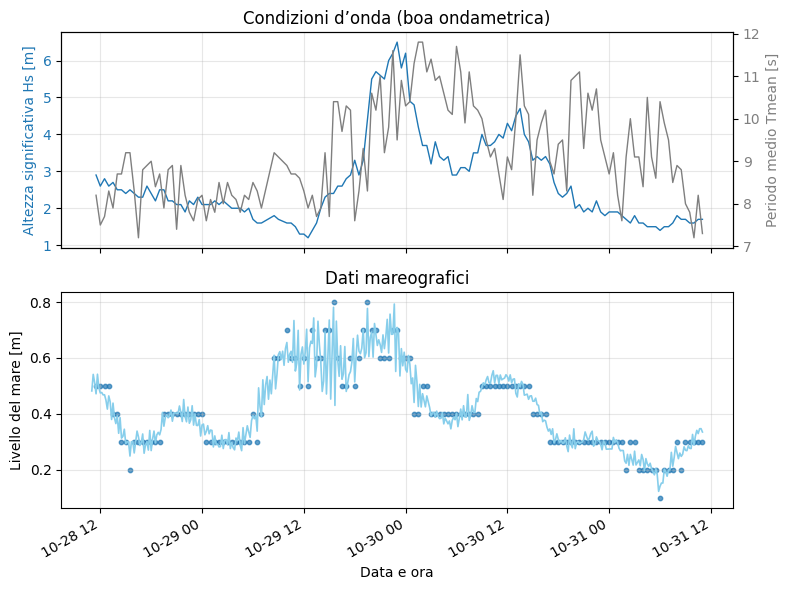

In [17]:
# --- 📈 Visualizzazione combinata con linea di marea completa + punti ai tempi delle onde ---

# 1) Assicuriamoci che l'indice temporale sia impostato correttamente
waves_tides = waves_tides.set_index('time') if 'time' in waves_tides.columns else waves_tides
tides_line = tides_df_pert.sort_index()  # linea continua (serie completa)
waves_points = waves_tides.sort_index()  # punti ai tempi delle onde (post-merge)

# 2) Crea la figura: 2 righe, 1 colonna
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# === Pannello superiore: Onde ===
ax1 = axs[0]          # asse principale (sinistro)
ax2 = ax1.twinx()     # asse secondario (destro)

# Hs (altezza significativa) su asse Y principale
waves_points['Hs'].plot(ax=ax1, color='tab:blue', lw=1)
ax1.set_ylabel('Altezza significativa Hs [m]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Tmean (periodo medio) su asse Y secondario
waves_points['Tmean'].plot(ax=ax2, color='tab:gray', lw=1)
ax2.set_ylabel('Periodo medio Tmean [s]', color='tab:gray')
ax2.tick_params(axis='y', labelcolor='tab:gray')

# Opzionale: titolino
ax1.set_title('Condizioni d’onda (boa ondametrica)')

# === Pannello inferiore: Maree ===
# Linea continua: marea perturbata completa
tides_line['WaterLevel'].plot(ax=axs[1], color='skyblue', lw=1.2, label='Marea (perturbata) — linea continua')

# Punti: valori di marea ai tempi delle onde (dal merge)
# NB: qui usiamo la colonna WaterLevel già allineata nel DataFrame unito
axs[1].scatter(
    waves_points.index,                  # tempi delle onde (dopo il merge)
    waves_points['WaterLevel'],          # livello marea corrispondente
    s=10,                                # dimensione punti
    alpha=0.7,
    label='Marea ai tempi delle onde (punti)'
)

axs[1].set_ylabel('Livello del mare [m]')
axs[1].set_xlabel('Data e ora')
axs[1].set_title('Dati mareografici')

# Migliorie grafiche
for ax in axs:
    ax.grid(True, alpha=0.3)
plt.tight_layout()

# Salvataggio
output_path = os.path.join(results_dir, 'waves_tides_plot.png')
fig.savefig(output_path, dpi=300)
plt.show()

## 💾 Esportazione del dataset combinato onde–maree

A questo punto, esportiamo il **dataset unito** `waves_tides` in formato **CSV** nella cartella `Risultati`, che abbiamo creato in precedenza.

---

### 📂 Contenuto del file
Il file salvato si chiama: `waves_tides_merged.csv`

e contiene, per ogni istante temporale, le variabili principali già allineate:

- `Hs` → altezza significativa dell’onda (m)  
- `Tmean` → periodo medio dell’onda (s)  
- `WaterLevel` → livello del mare (m)  
- `time_diff` → differenza temporale tra la misura d’onda e quella di marea (in minuti)

---

### 🧭 Come usare il file
Puoi trovare il file nella sottocartella: `Risultati/`

all’interno della directory di lavoro del notebook.  
Da qui puoi:
- aprirlo in **Excel**, **LibreOffice** o **QGIS** per visualizzare e analizzare i dati;  
- ricaricarlo in Python con `pd.read_csv()`;  
- allegarlo a una relazione o a un report di laboratorio.

💡 *Suggerimento:* mantenere tutti i risultati nella cartella `Risultati/` ti aiuterà a conservare il tuo lavoro in modo ordinato e riproducibile.

In [18]:
# --- 💾 Esportazione del dataset combinato onde + maree nella cartella "Risultati" ---

# Nome e percorso completo del file da esportare
output_filename = "waves_tides_merged.csv"
output_path = os.path.join(results_dir, output_filename)

# Salva il DataFrame in formato CSV
waves_tides.to_csv(output_path, index=True, sep=';', float_format='%.3f')

print(f"✅ File esportato correttamente in:\n{output_path}")

# Mostra le prime righe per controllo
pd.read_csv(output_path, sep=';').head()

✅ File esportato correttamente in:
/content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup/Risultati/waves_tides_merged.csv


,time,Hs,Hmax,Tpeak,Tmean,dates,DATE,TIME,WaterLevel,time_diff
0,2018-10-28 11:30:00,2.9,4.61,7.32,8.2,2018-10-28 11:30:00,20181028,11:30,0.5,0.0
1,2018-10-28 12:00:00,2.6,3.98,7.03,7.5,2018-10-28 12:00:00,20181028,12:00,0.5,0.0
2,2018-10-28 12:30:00,2.8,4.14,7.62,7.7,2018-10-28 12:30:00,20181028,12:30,0.5,0.0
3,2018-10-28 13:00:00,2.6,4.22,8.01,8.3,2018-10-28 13:00:00,20181028,13:00,0.5,0.0
4,2018-10-28 13:30:00,2.7,4.06,8.20,7.9,2018-10-28 13:30:00,20181028,13:30,0.4,0.0


## 🏖️ Inserimento di 10 pendenze di spiaggia (tanβ) + salvataggio e istogrammi

In questa sezione inserirai **10 valori di pendenza della spiaggia** (*tanβ*), che useremo:
- per stimare una distribuzione realistica delle pendenze;
- per campionare una **serie temporale** di pendenza da associare alle condizioni d’onda e di marea.

I 10 valori inseriti verranno salvati in: `Risultati/beach_slopes_input.csv`

e verranno prodotti due istogrammi (dei valori inseriti e della serie campionata) nella stessa cartella.

---

### 📘 Che cos’è la pendenza della spiaggia (tanβ)
La pendenza della spiaggia è, in prima approssimazione, il **rapporto tra dislivello e distanza orizzontale** nel tratto emerso interessato dal runup (la *foreshore*):
$$
\tan \beta = \frac{\Delta z}{\Delta x}
$$
- Esempi:  
  - *tanβ* = 0.05 → 5 cm di dislivello ogni 1 m in orizzontale (≈ 2.86°)  
  - *tanβ* = 0.10 → 10 cm/m (≈ 5.71°)

> 🔁 **Conversioni utili**  
> - Da **gradi** a *tanβ*: `tanβ = tan(θ in radianti)`  
> - Da **% pendenza** a *tanβ*: `tanβ = pendenza_% / 100`

**Ordini di grandezza tipici** (possono variare molto!):  
- spiagge sabbiose poco inclinate: *tanβ* ≈ 0.01–0.05  
- spiagge più ripide/ghiaiose: *tanβ* ≈ 0.05–0.15

---

### 🛰️ Come ricavare *tanβ* da un DEM in **QGIS**
Avrai un **Digital Elevation Model** (DEM) e un **video tutorial** dedicato. Ecco due approcci comuni:

1. **Profilo topografico perpendicolare alla costa**  
   - Traccia una linea dalla battigia verso terra (perpendicolare alla costa).  
   - Estrai il profilo di quota (Tool: *Profile Tool* o *Sample raster values*).  
   - Seleziona un tratto **foreshore** rappresentativo (es. tra MSL e berm crest) e calcola \(\Delta z / \Delta x\) (fit lineare o differenza tra estremi).  
   - Ripeti in più punti lungo la spiaggia → otterrai una piccola **collezione di *tanβ***.

2. **Mappa di pendenza (Slope)**  
   - Calcola la **pendenza** del DEM (Raster → Terrain analysis → *Slope*).  
   - Otterrai pendenza in **gradi** o in **%**.  
   - Converti a *tanβ* con le formule di cui sopra e campiona valori nella **fascia foreshore** (evita dune o retrospiaggia).

> ✅ **Consigli pratici**
> - Usa una **finestra di misura coerente** con la scala del runup (qualche decina di metri).  
> - Evita zone **alterate** (strutture rigide, canali, corpi detritici effimeri).  
> - Fai più misure lungo costa e **annota outlier** (valori anomali).

---

### ✍️ Cosa inserire qui
- Inserisci **10 valori di *tanβ*** (positivi), uno alla volta, quando richiesto dal notebook.  
- Se in QGIS ottieni **gradi** o **%**, **converti** prima in *tanβ*.  
- Se tutte le misure sono uguali (o quasi), va bene: il notebook gestisce comunque la campionatura.

---

### 📊 Cosa produce il codice
1. Salva i 10 valori in `Risultati/beach_slopes_input.csv`.  
2. Crea una **serie campionata** di pendenza (stessa lunghezza di `waves_tides`) centrata sui tuoi valori → aggiunta come colonna `slope`.  
3. Esporta due istogrammi:
   - `hist_pendenze_inserite.png` → distribuzione dei 10 valori immessi;  
   - `hist_pendenze_campionate.png` → distribuzione della serie campionata.

Questi output ti permettono di verificare che i valori immessi siano **realistici e coerenti** con la morfodinamica locale.

---

### 🧠 Perché ci serve *tanβ*?
La pendenza della spiaggia è uno dei **parametri chiave** in molti modelli di **wave runup**: influisce su quanto l’onda riesce a “risalire” sulla battigia.  
Usare una stima realistica (da DEM) migliora **affidabilità e trasferibilità** delle simulazioni.

Inserisci 10 valori di pendenza della spiaggia (tanβ). Esempio: 0.04
Pendenza 1/10: 0.01
Pendenza 2/10: 0.02
Pendenza 3/10: 0.03
Pendenza 4/10: 0.04
Pendenza 5/10: 0.06
Pendenza 6/10: 0.08
Pendenza 7/10: 0.05
Pendenza 8/10: 0.06
Pendenza 9/10: 0.03
Pendenza 10/10: 0.02
✅ Pendenze inserite salvate in: /content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup/Risultati/beach_slopes_input.csv


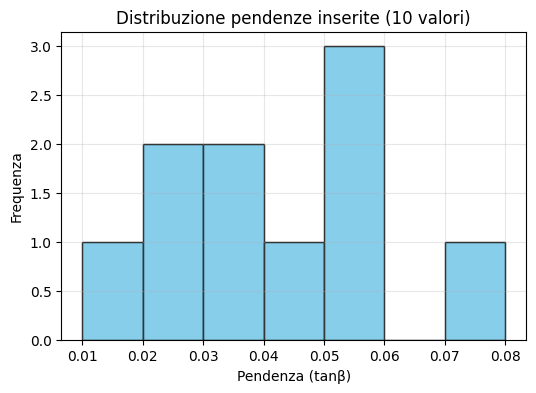

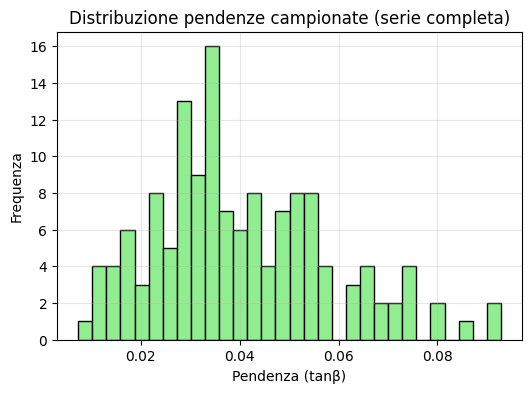

✅ Serie 'slope' aggiunta a waves_tides.
📊 Istogrammi salvati in:
- /content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup/Risultati/hist_pendenze_inserite.png
- /content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup/Risultati/hist_pendenze_campionate.png


In [22]:
# --- 🏖️ Input di 10 pendenze, salvataggio CSV e istogrammi nella cartella "Risultati" ---

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assicuriamoci che la cartella Risultati esista
os.makedirs(results_dir, exist_ok=True)

# 1️⃣ Raccogli 10 pendenze dall'utente (una per volta)
user_slopes = []
print("Inserisci 10 valori di pendenza della spiaggia (tanβ). Esempio: 0.04")
for i in range(1, 11):
    while True:
        raw = input(f"Pendenza {i}/10: ").strip().replace(",", ".")
        try:
            val = float(raw)
            if val <= 0:
                print("⚠️  La pendenza deve essere positiva. Riprova.")
                continue
            user_slopes.append(val)
            break
        except ValueError:
            print("⚠️  Valore non valido. Inserisci un numero (es. 0.045).")

# 2️⃣ Salva SOLO le pendenze inserite in CSV
inputs_df = pd.DataFrame({"slope_input": user_slopes}, index=range(1, 11))
input_csv_path = os.path.join(results_dir, "beach_slopes_input.csv")
inputs_df.to_csv(input_csv_path, sep=";", float_format="%.5f")
print(f"✅ Pendenze inserite salvate in: {input_csv_path}")

# 3️⃣ Genera la serie di pendenze campionate (distribuzione realistica)
def generate_random_slopes(slope_list, length, rng):
    mean_slope = float(np.mean(slope_list))
    std_slope = float(np.std(slope_list))
    if std_slope < 1e-6:
        std_slope = max(0.1 * mean_slope, 1e-4)
    while True:
        slopes = rng.normal(loc=mean_slope, scale=std_slope, size=length)
        if np.all(slopes > 0):
            return slopes

slope_series = generate_random_slopes(user_slopes, len(waves_tides), rng)

# Aggiungi la serie al DataFrame unito
waves_tides["slope"] = slope_series

# 4️⃣ Istogramma dei valori inseriti
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.hist(user_slopes, bins=min(10, len(set(user_slopes))), edgecolor="black", color="skyblue")
ax1.set_title("Distribuzione pendenze inserite (10 valori)")
ax1.set_xlabel("Pendenza (tanβ)")
ax1.set_ylabel("Frequenza")
ax1.grid(True, alpha=0.3)

input_hist_path = os.path.join(results_dir, "hist_pendenze_inserite.png")
fig1.savefig(input_hist_path, dpi=300, bbox_inches="tight")
plt.show()

# 5️⃣ Istogramma della serie campionata
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.hist(slope_series, bins=30, edgecolor="black", color="lightgreen")
ax2.set_title("Distribuzione pendenze campionate (serie completa)")
ax2.set_xlabel("Pendenza (tanβ)")
ax2.set_ylabel("Frequenza")
ax2.grid(True, alpha=0.3)

sampled_hist_path = os.path.join(results_dir, "hist_pendenze_campionate.png")
fig2.savefig(sampled_hist_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Serie 'slope' aggiunta a waves_tides.")
print(f"📊 Istogrammi salvati in:\n- {input_hist_path}\n- {sampled_hist_path}")

## 🌊 Calcolo del *Wave Runup* con modelli empirici

### 🔍 Che cos’è il *wave runup*?

Il **wave runup** è la massima estensione verticale raggiunta dalle onde quando si infrangono e risalgono sulla spiaggia.  
È controllato principalmente da tre fattori:

- **Altezza e periodo dell’onda**
- **Pendenza della spiaggia**
- **Livello di marea**

Il *runup* è una variabile fondamentale negli studi costieri, perché consente di stimare il rischio di **allagamento** e **erosione** costiera — specialmente se considerato insieme all’**innalzamento del livello del mare** (*sea level rise*).

<div style="text-align: center">
    <img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-017-01362-7/MediaObjects/41598_2017_1362_Fig1_HTML.jpg?as=webp" width="600">
    <br>
    <small><b>Figura:</b> Componenti del *wave runup*. Fonte: Vitousek et al. (2017), <i>Scientific Reports</i>.  
    <a href="https://doi.org/10.1038/s41598-017-01362-7" target="_blank">https://doi.org/10.1038/s41598-017-01362-7</a></small>
</div>

---

### 🧩 Cosa significa “modello empirico”?

Un **modello empirico** è una formula o relazione matematica che si basa su **osservazioni e misure sperimentali**, più che su una teoria fisica completa.  
In pratica, i ricercatori raccolgono **dati reali** (ad esempio misure di onde, maree e runup su diverse spiagge) e cercano di identificare **correlazioni** tra le variabili principali.

Nel caso del *wave runup*, un modello empirico tipicamente esprime una relazione del tipo:

$$
R_2 = f(H_s, T_p, \tan\beta)
$$

dove:
- \( R_2 \) è il runup al 2% di superamento (quota raggiunta solo dalle onde più energetiche),
- \( H_s \) è l’altezza significativa dell’onda,
- \( T_p \) o \( T_{mean} \) è il periodo d’onda,
- \( $\tan\beta$ \) è la pendenza della spiaggia.

🔹 **Vantaggi:**  
- sono **veloci da applicare** e richiedono poche variabili;  
- permettono di stimare il runup in assenza di misure dirette.  

🔸 **Limiti:**  
- derivano da **condizioni sperimentali specifiche**, per cui possono funzionare meglio solo su spiagge simili a quelle di calibrazione;  
- non descrivono i processi fisici nel dettaglio, ma ne **riassumono il comportamento medio**.

> 💡 In sintesi: i modelli empirici sono strumenti pratici, nati da dati reali, che semplificano la complessità fisica per fornire stime rapide e utili del runup.

---

### 🧠 Cosa stiamo facendo in questo passaggio

In questa fase applichiamo **diversi modelli empirici pubblicati in letteratura** per stimare il livello di *runup* al **2% di superamento** (*R2*), che rappresenta la quota di battigia raggiunta durante le condizioni più energetiche.

Ogni modello utilizza come input:
- **Hs** → altezza significativa dell’onda  
- **Tp (o Tmean)** → periodo medio dell’onda  
- **β** → pendenza della spiaggia (*tanβ*)  
- **Livello di marea** → sommato a R2 per ottenere l’**altezza totale dell’acqua** in battigia (*Total Water Level*)

I modelli implementati sono:
- Stockdon et al. (2006)  
- Vousdoukas et al. (2012)  
- Holman (1986)  
- Nielsen (2009)  
- Ruggiero et al. (2001)  
- Atkinson et al. (2017)  
- Senechal et al. (2011)  
- Passarella et al. (2018)

Il risultato è un nuovo **DataFrame** con il *runup* stimato da ciascun modello, più una colonna con la **media d’ensemble**, utile per confrontare le diverse formulazioni.

---

### 📦 Sul pacchetto `py-wave-runup`

Tutti questi modelli sono implementati nella libreria open-source  
[`py-wave-runup`](https://py-wave-runup.readthedocs.io/en/latest/?badge=latest), sviluppata da **Chris Leaman**.

> 📚 **Documentazione ufficiale:**  
> [https://py-wave-runup.readthedocs.io](https://py-wave-runup.readthedocs.io/en/latest/?badge=latest)

---

### 🧾 Citazioni e buone pratiche

⚠️ **È indispensabile citare correttamente i modelli di runup utilizzati.**  
Ogni modello corrisponde a un articolo scientifico, che deve essere riconosciuto quando i risultati vengono utilizzati in relazioni, tesi o pubblicazioni.

Troverai tutte le **citazioni complete** nella documentazione del pacchetto *py-wave-runup*.  
Nel corso ti verrà fornito un **tutorial dedicato su Zotero**, dove imparerai come:
- aggiungere riferimenti bibliografici corretti;  
- gestire i modelli empirici come fonti;  
- esportare automaticamente la bibliografia nei tuoi report.

💡 *Buona prassi:* quando riporti un risultato derivato da un modello, indica sempre tra parentesi il nome e l’anno, ad esempio:
> “Il runup è stato calcolato secondo la formulazione di Stockdon et al. (2006).”

---

📤 Alla fine del calcolo, i risultati di tutti i modelli vengono salvati in un file CSV nella cartella `Risultati/`, per ulteriori analisi e visualizzazioni.

In [27]:
# === 🧮 Calcolo del runup con più modelli + export in Risultati ===

# --- Step 1: estrai le variabili di input dal dataframe unito, come array numpy
# (uso .values per efficienza e per evitare problemi con oggetti pandas)
Hs   = pd.to_numeric(waves_tides['Hs'], errors='coerce').values
Tp   = pd.to_numeric(waves_tides['Tmean'], errors='coerce').values
tide = pd.to_numeric(waves_tides['WaterLevel'], errors='coerce').values
beta = pd.to_numeric(waves_tides['slope'], errors='coerce').values

# Mantieni anche l'asse temporale, se disponibile
time_index = pd.to_datetime(waves_tides['time'], errors='coerce') if 'time' in waves_tides.columns else None

# --- Step 1b: maschera per righe valide (evita NaN in qualsiasi input)
mask_valid = np.isfinite(Hs) & np.isfinite(Tp) & np.isfinite(tide) & np.isfinite(beta)
if not mask_valid.all():
    # Applica la maschera ai vettori
    Hs, Tp, tide, beta = Hs[mask_valid], Tp[mask_valid], tide[mask_valid], beta[mask_valid]
    # Se esiste il tempo, maschera anche quello
    if time_index is not None:
        time_index = pd.to_datetime(time_index[mask_valid])

# --- Step 2: calcola il runup con i vari modelli
# Nota: i modelli restituiscono R2 (eccetto Passarella2018 che qui usiamo .swash)
runup_dict = {
    'Stockdon et al. (2006)':   (models.Stockdon2006(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Vousdoukas et al. (2012)': (models.Vousdoukas2012(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Holman (1986)':            (models.Holman1986(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Nielsen (2009)':           (models.Nielsen2009(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Ruggiero et al. (2001)':   (models.Ruggiero2001(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Atkinson et al. (2017)':   (models.Atkinson2017(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Senechal et al. (2011)':   (models.Senechal2011(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Passarella et al. (2018)': (models.Passarella2018(Hs=Hs, Tp=Tp, beta=beta)).swash + tide
}

# --- Step 3: costruiamo il DataFrame risultati e aggiungiamo riferimenti
R2 = pd.DataFrame(runup_dict)

# aggiungi le variabili di input per riferimento
R2['Hs']         = Hs
R2['Tmean']      = Tp
R2['WaterLevel'] = tide
R2['slope']      = beta

# aggiungi il tempo se disponibile
if time_index is not None:
    R2.insert(0, 'time', time_index)

# colonna d’aiuto: media tra modelli (escludendo Passarella se vuoi solo R2 “classici”)
runup_cols = [
    'Stockdon et al. (2006)',
    'Vousdoukas et al. (2012)',
    'Holman (1986)',
    'Nielsen (2009)',
    'Ruggiero et al. (2001)',
    'Atkinson et al. (2017)',
    'Senechal et al. (2011)',
    'Passarella et al. (2018)'
]
R2['Runup_ensemble_mean'] = R2[runup_cols].mean(axis=1)

# --- Step 4: esporta in CSV dentro "Risultati"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
outfile = os.path.join(results_dir, f"runup_results_{timestamp}.csv")
R2.to_csv(outfile, index=False)

print(f"✅ Runup calcolato con {len(runup_cols)} modelli.")
print(f"💾 File esportato in: {outfile}")

✅ Runup calcolato con 8 modelli.
💾 File esportato in: /content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup/Risultati/runup_results_20251029_090807.csv


## 📊 Confronto tra i modelli empirici di *wave runup*

In questa sezione visualizziamo i risultati del calcolo del *runup* attraverso una serie di **istogrammi comparativi**.  
Ogni istogramma mostra la distribuzione dei valori di *runup* stimati da uno dei modelli empirici utilizzati.

---

### 🧩 Cosa rappresentano gli istogrammi
- Ogni pannello mostra la **frequenza dei valori di runup** (asse Y) per intervalli di ampiezza **0.2 m** (bin fissi).  
- Tutti gli istogrammi condividono la **stessa scala** sugli assi X e Y, così da poter confrontare visivamente le distribuzioni.  
- L’ultimo pannello (in basso a destra) mostra **tutti i modelli combinati**: le distribuzioni si sovrappongono parzialmente, permettendo di valutare la **variabilità complessiva** tra modelli.

---

### 🔍 Come interpretare i grafici
- La **posizione del picco** indica il valore di runup più frequente stimato dal modello.  
- La **larghezza della distribuzione** riflette la variabilità del modello rispetto alle condizioni di onda e marea.  
- Differenze tra modelli possono derivare da:
  - la formulazione empirica originale (spiagge o regimi d’onda diversi);
  - la sensibilità alla pendenza della spiaggia (*tanβ*);
  - la presenza o meno di componenti di swash (*swash height*).

> 💡 *Esempio di lettura:*  
> Se un modello mostra una distribuzione più spostata verso destra (runup più alti), significa che tende a **sovrastimare** le condizioni di runup massimo rispetto ad altri.

---

### 📦 Risultato esportato
L’intera figura viene salvata automaticamente nella cartella: Risultati/runup_histograms_all_models.png

Puoi inserire questa immagine nella tua **relazione di laboratorio** o nel **report finale**, accompagnandola con un breve commento comparativo:
- Quali modelli producono runup più elevati?  
- Quali mostrano distribuzioni più strette o più ampie?  
- Come si confrontano i risultati con la tua aspettativa sulla morfologia della spiaggia?

---

### 🧠 Obiettivo didattico
Questo confronto serve per comprendere che:
- I **modelli empirici** non restituiscono un unico valore “vero” di runup, ma un **insieme di stime**.  
- La **dispersione tra modelli** è una misura utile dell’**incertezza** del calcolo.  
- L’analisi congiunta dei risultati (ensemble mean, distribuzioni) consente di formulare una **valutazione più robusta** dei livelli marini estremi.

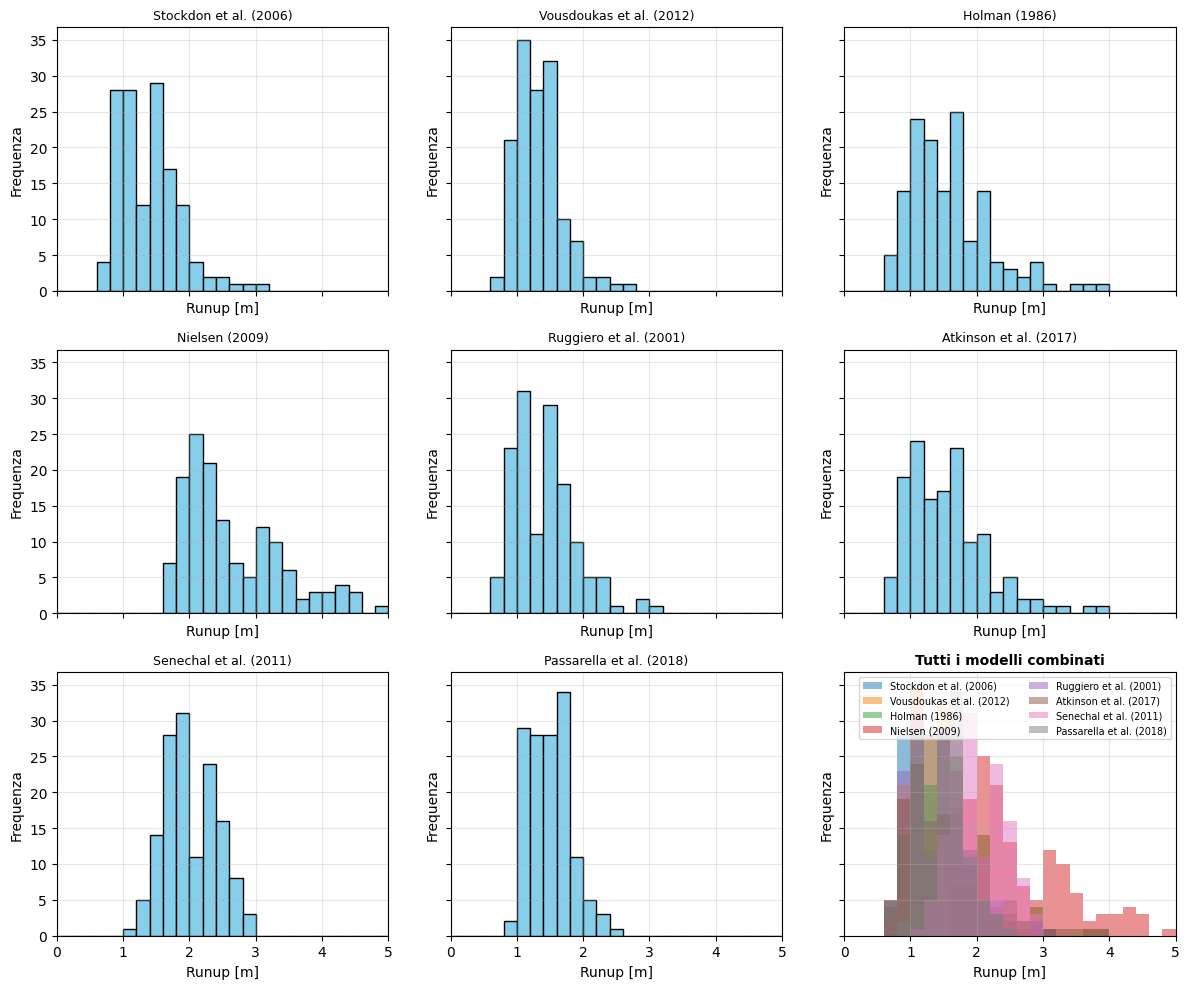

✅ Istogrammi salvati in: /content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup/Risultati/runup_histograms_all_models.png


In [35]:
# --- 📊 Istogrammi comparativi dei risultati di runup per ciascun modello empirico ---

import numpy as np
import matplotlib.pyplot as plt
import os

# Numero di modelli e griglia
n_models = len(runup_cols)
n_rows, n_cols = 3, 3  # 8 modelli + 1 combinato

# Calcola limiti comuni e bin fissi (ampiezza 0.2 m)
all_values = np.concatenate([R2[col].dropna().values for col in runup_cols])
xmin, xmax = np.floor(all_values.min()), np.ceil(all_values.max())
bin_width = 0.2
bins = np.arange(xmin, xmax + bin_width, bin_width)

# Crea figura con assi condivisi
fig, axs = plt.subplots(
    n_rows, n_cols,
    figsize=(12, 10),
    sharex=True,
    sharey=True
)
axs = axs.flatten()

# --- 1️⃣ Istogrammi individuali ---
for i, col in enumerate(runup_cols):
    axs[i].hist(R2[col], bins=bins, color='skyblue', edgecolor='black')
    axs[i].set_title(col, fontsize=9)
    axs[i].set_xlabel('Runup [m]')
    axs[i].set_ylabel('Frequenza')
    axs[i].grid(True, alpha=0.3)
    axs[i].set_xlim(xmin, xmax)

# --- 2️⃣ Istogramma combinato (tutti i modelli insieme) ---
combined_ax = axs[min(n_models, len(axs)-1)]
for col in runup_cols:
    combined_ax.hist(R2[col], bins=bins, alpha=0.5, label=col)
combined_ax.set_title('Tutti i modelli combinati', fontsize=10, fontweight='bold')
combined_ax.set_xlabel('Runup [m]')
combined_ax.set_ylabel('Frequenza')
combined_ax.legend(fontsize='x-small', loc='upper right', ncol=2)
combined_ax.grid(True, alpha=0.3)
combined_ax.set_xlim(xmin, xmax)

# --- 3️⃣ Rimuovi eventuali subplot vuoti (se < 9 modelli) ---
if len(axs) > n_models + 1:
    for ax in axs[n_models + 1:]:
        ax.axis('off')

# --- 4️⃣ Migliora layout e salva ---
plt.tight_layout()
hist_output_path = os.path.join(results_dir, "runup_histograms_all_models.png")
fig.savefig(hist_output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✅ Istogrammi salvati in: {hist_output_path}")

## 📈 Analisi ensemble dei modelli di *wave runup*

Dopo aver calcolato il runup con diversi modelli empirici, possiamo combinarne i risultati per ottenere una **visione d’insieme** del comportamento stimato.  
Questo approccio è detto **analisi ensemble**.

---

### 🧩 Che cos’è un *ensemble* di modelli
Un **ensemble** è un insieme di più modelli che stimano la stessa variabile (in questo caso, il *runup*).  
L’idea è che ogni modello rappresenti una prospettiva diversa — basata su spiagge, dati o approcci sperimentali differenti — e che la loro combinazione fornisca una stima **più robusta e meno dipendente** da un singolo metodo.

> 💡 In pratica, non esiste un “modello perfetto”: l’ensemble serve per sintetizzare il comportamento medio e quantificare l’incertezza tra i modelli.

---

### 📊 Cosa mostra il grafico
Il grafico riassume l’evoluzione temporale del *runup* stimato, con tre elementi principali:

- 🔵 **Banda azzurra (5°–95° percentile)** → rappresenta l’intervallo di incertezza tra i modelli:  
  più è ampia, maggiore è la dispersione (disaccordo) tra le formulazioni.  

- ⚫ **Linea blu (50° percentile)** → indica la **mediana** dell’ensemble, cioè il valore “centrale” (la metà dei modelli stima un runup superiore e metà inferiore).  

- 🔴 **Linea rossa tratteggiata (media ensemble)** → è la media dei valori restituiti dai modelli, utile per confronti quantitativi.  

---

### 🧠 Come interpretare
- Se la **banda azzurra è stretta**, i modelli sono coerenti → alta affidabilità.  
- Se la **banda è ampia**, i modelli divergono → incertezza maggiore, spesso legata a condizioni limite o parametri sensibili (ad es. spiagge molto ripide).  
- Differenze tra media e mediana possono indicare **asimmetrie** nella distribuzione dei valori di runup.

---

### 📦 Output
Il grafico viene salvato automaticamente in: `Risultati/runup_ensemble_statistics.png`

Puoi includerlo nella tua **relazione finale** per mostrare:
- l’intervallo di variabilità tra modelli;  
- la coerenza temporale del runup stimato;  
- la tua valutazione personale dell’incertezza del modello.

---

### 🎯 Obiettivo didattico
Questa sezione introduce il concetto di **modellazione ensemble** e di **incertezza scientifica**:  
capire che i modelli empirici forniscono stime diverse non è un problema, ma un’informazione preziosa per interpretare la **variabilità naturale** e la **robustezza delle previsioni costiere**.

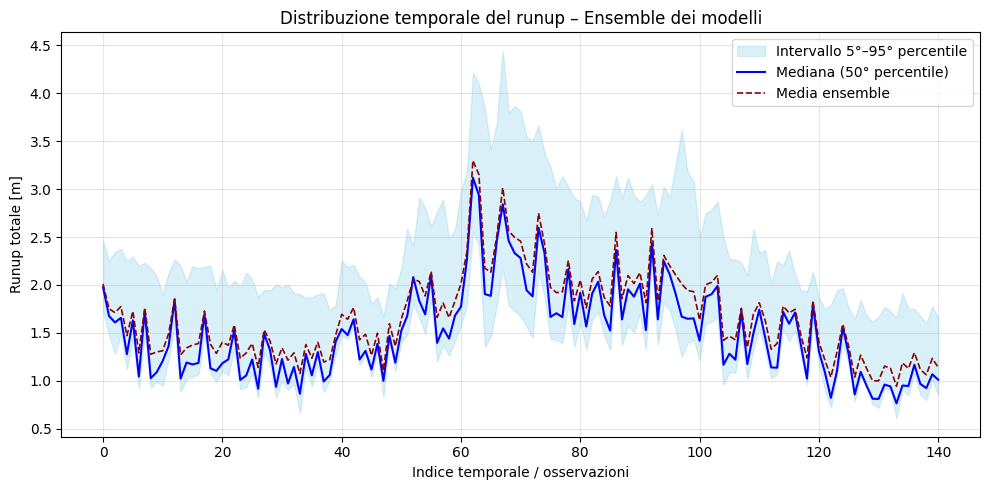

✅ Analisi ensemble completata.
📊 Figura salvata in: /content/drive/Othercomputers/My Mac/Documents/GitHub/Esercitazione_GGG/Wave_Runup/Risultati/runup_ensemble_statistics.png


In [37]:
# --- 📈 Analisi statistica dell’ensemble di modelli di runup (opzionale) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Seleziona solo le colonne dei modelli di runup
ensemble = R2[runup_cols]

# Calcolo delle statistiche principali
runup_mean = ensemble.mean(axis=1)
runup_p05  = ensemble.quantile(0.05, axis=1)
runup_p50  = ensemble.quantile(0.50, axis=1)
runup_p95  = ensemble.quantile(0.95, axis=1)

# Aggiunge le statistiche al dataframe principale (se non già presenti)
R2["Runup_ensemble_mean"] = runup_mean
R2["Runup_p05"] = runup_p05
R2["Runup_p50"] = runup_p50
R2["Runup_p95"] = runup_p95

# --- 📊 Grafico delle statistiche ensemble ---

fig, ax = plt.subplots(figsize=(10, 5))

# Banda di incertezza (5°–95° percentile)
ax.fill_between(
    R2.index,
    R2["Runup_p05"],
    R2["Runup_p95"],
    color="skyblue",
    alpha=0.3,
    label="Intervallo 5°–95° percentile"
)

# Linea mediana (50° percentile)
ax.plot(R2.index, R2["Runup_p50"], color="blue", lw=1.5, label="Mediana (50° percentile)")

# Linea media ensemble
ax.plot(R2.index, R2["Runup_ensemble_mean"], color="darkred", lw=1.2, linestyle="--", label="Media ensemble")

ax.set_title("Distribuzione temporale del runup – Ensemble dei modelli", fontsize=12)
ax.set_xlabel("Indice temporale / osservazioni")
ax.set_ylabel("Runup totale [m]")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

# Salvataggio nella cartella Risultati
summary_plot_path = os.path.join(results_dir, "runup_ensemble_statistics.png")
fig.savefig(summary_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("✅ Analisi ensemble completata.")
print(f"📊 Figura salvata in: {summary_plot_path}")

## 🗺️ Dalla modellazione al GIS: scelta dei valori di *runup* da mappare

Dopo aver stimato il *wave runup* con diversi modelli empirici, possiamo passare alla fase successiva dell’esercitazione:  
**rappresentare il runup su una mappa costiera** per individuare le aree potenzialmente inondate durante la mareggiata.

---

### 🎯 Obiettivo
Identificare uno o più **valori rappresentativi di runup** (*R₂*, media ensemble o percentili) da riportare in ambiente GIS, per stimare:
- la **massima estensione dell’inondazione** costiera;  
- le **aree più vulnerabili** lungo la spiaggia e nella retrospiaggia;  
- eventuali **interazioni con dune, infrastrutture o aree antropizzate**.

---

### 🧩 Come scegliere il valore di *runup* da mappare
1. **Scegli la metrica più adatta allo scenario di interesse:**
   - Per rappresentare un **evento medio–energetico**, utilizza la **mediana (50° percentile)** o la **media ensemble**.  
   - Per rappresentare uno **scenario estremo**, usa il **95° percentile** o il valore massimo tra i modelli.  
   - Se vuoi mostrare la **variabilità tra modelli**, puoi esportare più soglie (es. media, 50° e 95° percentile) e visualizzarle come “fasce di probabilità” di inondazione.

2. **Motiva la tua scelta** nella relazione tecnica:
   - spiega perché hai scelto quel valore (evento medio, evento estremo, confronto tra modelli);
   - commenta eventuali differenze tra modelli e percentili;

---

### 🗂️ Passaggio successivo: uso dei risultati in QGIS
Una volta scelto il valore di *runup* da mappare, lo userai in **QGIS** per identificare le aree inondate sul **Digital Elevation Model (DEM)** e sull’**ortofoto** della zona di studio.  
Questo ti permetterà di visualizzare le **quote di massima risalita** dell’onda sulla spiaggia e nella retrospiaggia.

> 📚 Le istruzioni pratiche per questa fase — inclusi i passaggi su QGIS e la redazione della relazione tecnica — saranno fornite in **tutorial dedicati**.

---

### 📄 Relazione tecnica finale

L’output richiesto di questa esercitazione è una **relazione tecnica sintetica** (massimo **5 pagine**, inclusa la bibliografia) che riassuma:

1. I **dati** utilizzati e le principali elaborazioni svolte nel notebook.  
2. I **modelli di runup** applicati e le **citazioni** corrispondenti (da inserire con Zotero).  
3. I **valori di runup** selezionati per la mappatura in QGIS e la motivazione della scelta.  
4. Le **mappe di inondazione** prodotte in QGIS e la loro interpretazione.  
5. Una breve **discussione critica** sui risultati e sulle fonti di incertezza.

> ✍️ *Obiettivo didattico:* dimostrare la capacità di collegare i risultati di un modello numerico con l’analisi spaziale in GIS, per interpretare un evento reale di **mareggiata e inondazione costiera**.


💡 *Ricorda:* la relazione non deve limitarsi a riportare numeri o mappe, ma deve mostrare **ragionamento critico** sul significato dei risultati e sulla loro attendibilità.

💡 *Ricorda:* la qualità della relazione dipenderà non solo dai risultati ottenuti, ma dalla **chiarezza del ragionamento**, dall’uso corretto delle **citazioni** e dalla **capacità di interpretare criticamente** i fenomeni costieri osservati.

💡 *Obiettivo finale:* integrare analisi numerica e rappresentazione spaziale per comprendere **come un evento di mareggiata può trasformarsi in un fenomeno di inondazione costiera reale**.

---

## 📝 Acknowledgments

This script was developed by **Alessio Rovere** at **Ca' Foscari University of Venice**, with the support of **ChatGPT by OpenAI** for code structuring, optimization, and documentation refinement.

⚠️ **Disclaimer:**  
The code is provided *as is*, without any warranties or guarantees of correctness. Users are responsible for verifying results and adapting the scripts to their specific needs. Neither the authors nor the European Union can be held responsible for any use that may be made of the information or code contained herein.